# 第 5 周第 3 课：分组比较与需求模式可视化

本 Notebook 将基于清洗后的共享单车数据：

- 比较工作日与非工作日的小时需求；
- 分析星期与小时组合；
- 比较季节编码和天气类别；
- 比较临时用户与注册用户；
- 展示样本量并控制结论边界。

主要分析口径为“有记录小时”；零需求缺失小时将在敏感性分析中单独处理。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = Path("../data/processed/hourly_clean.csv")
REPORT_DIR = Path("../reports/lesson-03")

assert DATA_PATH.exists(), f"找不到输入文件: {DATA_PATH.resolve()}"

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["dteday", "timestamp"],
)

In [2]:
required = {
    "timestamp",
    "dteday",
    "hr",
    "workingday",
    "weekday",
    "yr",
    "season",
    "weathersit",
    "casual",
    "registered",
    "cnt",
}

assert required.issubset(df.columns)
assert df.shape == (17_379, 26)
assert df[list(required)].notna().all().all()
assert df["timestamp"].is_unique
assert df["timestamp"].is_monotonic_increasing
assert df["cnt"].gt(0).all()
assert df["cnt"].eq(
    df["casual"] + df["registered"]
).all()
assert int(df["cnt"].sum()) == 3_292_679

print("第三课输入契约全部通过")

第三课输入契约全部通过


In [3]:
print(df.shape)
print(df["timestamp"].agg(["min", "max"]))
df.head(3).T

(17379, 26)
min   2011-01-01 00:00:00
max   2012-12-31 23:00:00
Name: timestamp, dtype: datetime64[ns]


,0,1,2
instant,1,2,3
dteday,2011-01-01 00:00:00,2011-01-01 00:00:00,2011-01-01 00:00:00
season,1,1,1
yr,0,0,0
mnth,1,1,1
hr,0,1,2
holiday,0,0,0
weekday,6,6,6
workingday,0,0,0
weathersit,1,1,1


In [4]:
day_type_labels = {
    0: "non_workingday",
    1: "workingday",
}

season_groups = {
    i: f"season_{i}"
    for i in range(1, 5)
}

weekday_order = [
    "Mon",
    "Tue",
    "Wed",
    "Thu",
    "Fri",
    "Sat",
    "Sun",
]

weekday_labels = {
    0: "Sun",
    1: "Mon",
    2: "Tue",
    3: "Wed",
    4: "Thu",
    5: "Fri",
    6: "Sat",
}

df["day_type"] = df["workingday"].map(day_type_labels)
df["season_group"] = df["season"].map(season_groups)
df["weekday_display"] = df["weekday"].map(weekday_labels)
df["year"] = df["dteday"].dt.year

In [5]:
dimension_columns = [
    "day_type",
    "season_group",
    "weekday_display",
]

assert df[dimension_columns].notna().all().all()

for column in dimension_columns:
    df[column] = df[column].astype("category")

assert df["year"].eq(df["yr"] + 2011).all()

assert (
    (df["dteday"].dt.dayofweek + 1) % 7
).eq(df["weekday"]).all()

print("展示维度验证通过")

展示维度验证通过


In [6]:
print(df[dimension_columns].dtypes)
print()
print(df["day_type"].value_counts())
print()
print(df["season_group"].value_counts().sort_index())
print()
print(df["weekday_display"].value_counts())

day_type           category
season_group       category
weekday_display    category
dtype: object

day_type
workingday        11865
non_workingday     5514
Name: count, dtype: int64

season_group
season_1    4242
season_2    4409
season_3    4496
season_4    4232
Name: count, dtype: int64

weekday_display
Sat    2512
Sun    2502
Fri    2487
Mon    2479
Wed    2475
Thu    2471
Tue    2453
Name: count, dtype: int64


In [7]:
hourly_summary = (
    df.groupby(
        "hr",
        as_index=False,
    )
    .agg(
        sample_count=("cnt", "size"),
        total_rentals=("cnt", "sum"),
        mean_rentals=("cnt", "mean"),
        median_rentals=("cnt", "median"),
        p95_rentals=(
            "cnt",
            lambda values: values.quantile(0.95),
        ),
    )
)

In [8]:
assert len(hourly_summary) == 24

assert (
    hourly_summary["sample_count"].sum()
    == len(df)
)

assert (
    hourly_summary["total_rentals"].sum()
    == df["cnt"].sum()
)

print("小时汇总验证通过")
hourly_summary

小时汇总验证通过


,hr,sample_count,total_rentals,mean_rentals,median_rentals,p95_rentals
0,0,726,39130,53.898072,40.0,144.75
1,1,724,24164,33.375691,20.0,113.00
2,2,715,16352,22.869930,11.0,81.30
3,3,697,8174,11.727403,6.0,42.00
4,4,697,4428,6.352941,6.0,14.00
5,5,717,14261,19.889819,19.0,42.00
6,6,725,55132,76.044138,76.0,172.00
7,7,727,154171,212.064649,208.0,503.00
8,8,727,261001,359.011004,385.0,737.00
9,9,727,159438,219.309491,216.0,365.70


In [9]:
hour_day = (
    df.groupby(
        ["day_type", "hr"],
        as_index=False,
        observed=True,
    )
    .agg(
        sample_count=("cnt", "size"),
        total_rentals=("cnt", "sum"),
        mean_rentals=("cnt", "mean"),
        median_rentals=("cnt", "median"),
    )
)

In [10]:
assert len(hour_day) == 48
assert hour_day["sample_count"].sum() == len(df)
assert hour_day["total_rentals"].sum() == df["cnt"].sum()

print("日类型 × 小时汇总验证通过")
hour_day.head(10)

日类型 × 小时汇总验证通过


,day_type,hr,sample_count,total_rentals,mean_rentals,median_rentals
0,non_workingday,0,230,20884,90.800000,93.5
1,non_workingday,1,230,15987,69.508696,71.0
2,non_workingday,2,228,12123,53.171053,54.0
3,non_workingday,3,227,5851,25.775330,25.0
4,non_workingday,4,227,1876,8.264317,7.0
5,non_workingday,5,222,1929,8.689189,7.0
6,non_workingday,6,229,4292,18.742358,16.0
7,non_workingday,7,231,10027,43.406926,39.0
8,non_workingday,8,231,24406,105.653680,94.0
9,non_workingday,9,231,39645,171.623377,170.0


In [11]:
peak_rows = (
    hour_day.groupby(
        "day_type",
        observed=True,
    )["median_rentals"]
    .idxmax()
)

peak_hours = hour_day.loc[
    peak_rows,
    [
        "day_type",
        "hr",
        "median_rentals",
        "sample_count",
    ],
]

peak_hours

,day_type,hr,median_rentals,sample_count
12,non_workingday,12,367.0,231
41,workingday,17,539.0,499


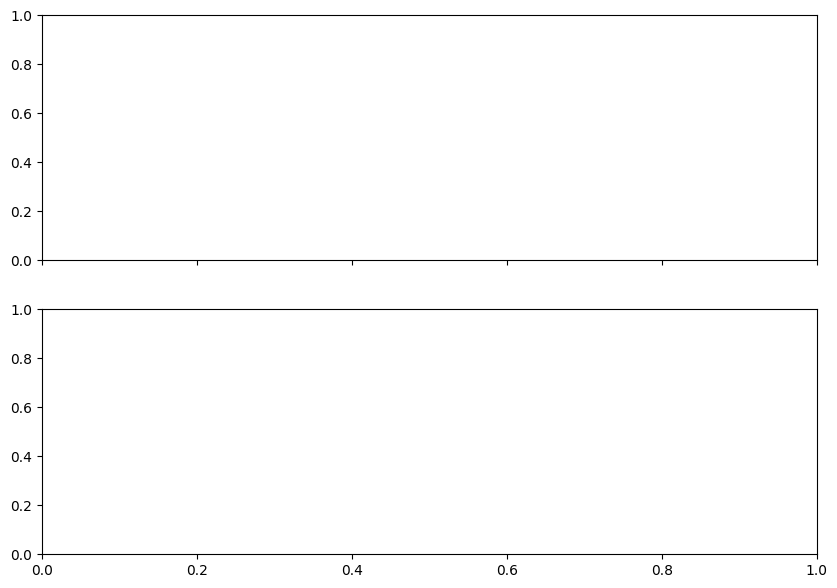

In [12]:
fig_hour, axes = plt.subplots(
    2,
    1,
    figsize=(10, 7),
    sharex=True,
)

In [13]:
for day_type, group in hour_day.groupby(
    "day_type",
    observed=True,
):
    group = group.sort_values("hr")

    axes[0].plot(
        group["hr"],
        group["median_rentals"],
        marker="o",
        label=day_type,
    )

In [14]:
for day_type, group in hour_day.groupby(
    "day_type",
    observed=True,
):
    group = group.sort_values("hr")

    axes[1].plot(
        group["hr"],
        group["sample_count"],
        marker="o",
        label=day_type,
    )

In [15]:
axes[0].set(
    title="Hourly demand by day type — recorded hours only",
    ylabel="Median rentals per recorded hour",
)
axes[0].legend()

axes[1].set(
    xlabel="Hour of day",
    ylabel="Recorded-hour count",
    xticks=range(24),
)

fig_hour.tight_layout()
plt.show()

In [16]:
workingday_top = (
    hour_day.loc[
        hour_day["day_type"].eq("workingday"),
        [
            "hr",
            "median_rentals",
            "sample_count",
        ],
    ]
    .sort_values(
        "median_rentals",
        ascending=False,
    )
    .head(6)
)

workingday_top

,hr,median_rentals,sample_count
41,17,539.0,499
42,18,504.5,498
32,8,463.0,496
43,19,349.5,498
31,7,295.0,496
40,16,292.0,499


In [17]:
non_workingday_top = (
    hour_day.loc[
        hour_day["day_type"].eq("non_workingday"),
        [
            "hr",
            "median_rentals",
            "sample_count",
        ],
    ]
    .sort_values(
        "median_rentals",
        ascending=False,
    )
    .head(6)
)

non_workingday_top

,hr,median_rentals,sample_count
12,12,367.0,231
13,13,367.0,231
15,15,361.0,231
14,14,361.0,231
16,16,356.0,231
17,17,322.0,231


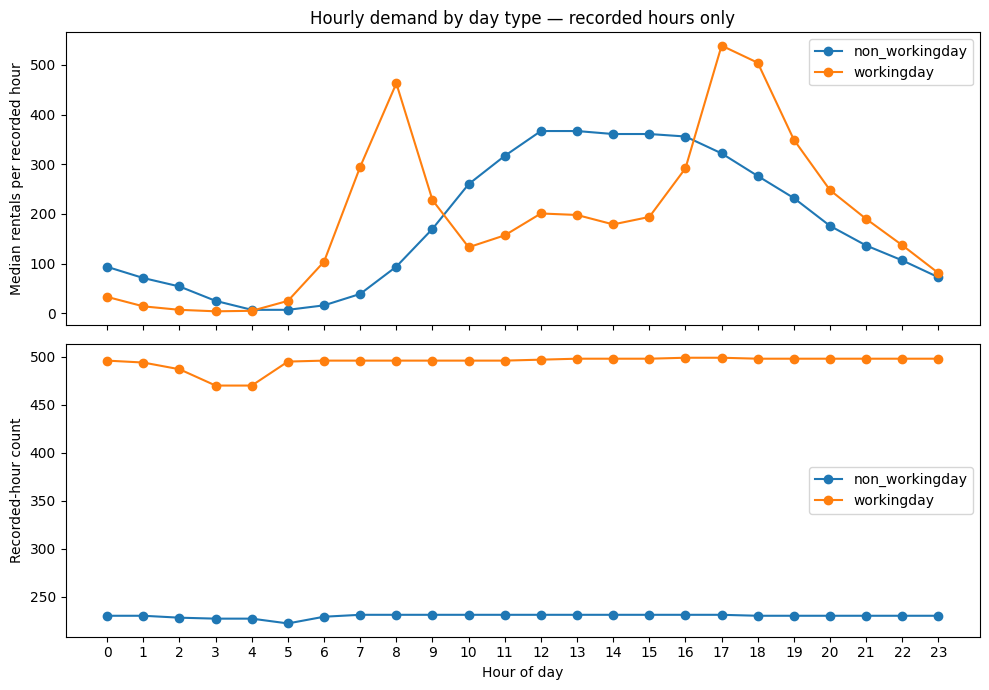

In [18]:
fig_hour, axes = plt.subplots(
    2,
    1,
    figsize=(10, 7),
    sharex=True,
)

for day_type, group in hour_day.groupby(
    "day_type",
    observed=True,
):
    group = group.sort_values("hr")

    # 上图：中位需求
    axes[0].plot(
        group["hr"],
        group["median_rentals"],
        marker="o",
        label=day_type,
    )

    # 下图：样本量
    axes[1].plot(
        group["hr"],
        group["sample_count"],
        marker="o",
        label=day_type,
    )

axes[0].set(
    title="Hourly demand by day type — recorded hours only",
    ylabel="Median rentals per recorded hour",
)
axes[0].legend()

axes[1].set(
    xlabel="Hour of day",
    ylabel="Recorded-hour count",
    xticks=range(24),
)
axes[1].legend()

fig_hour.tight_layout()
plt.show()

### 工作日与非工作日小时需求结论

**观察：** 工作日需求呈现早晚双峰，非工作日需求从中午到
下午形成较宽的高位区间。非工作日凌晨需求通常高于工作日。

**证据：** 工作日中位需求在 17 点达到最高值 539，样本量为
499；8 点的中位需求为 463，样本量为 496。非工作日 12 点和
13 点并列最高，中位需求均为 367，样本量均为 231。

**样本量：** 每个工作日钟点约有 470–500 条记录，非工作日
约有 220–231 条记录。凌晨 2–5 点的样本量略少，与已识别的
缺失小时分布一致。

**限制：** 图表仅包含有记录小时，并混合了两个年份、天气、
季节和节假日。曲线形状与通勤模式一致，但数据没有出行目的
字段，不能证明峰值由通勤直接导致。

**下一步：** 按年份分别绘制小时曲线，并比较补入零需求小时
后凌晨时段的均值变化。

In [19]:
weekday_hour = (
    df.groupby(
        ["weekday_display", "hr"],
        as_index=False,
        observed=True,
    )
    .agg(
        median_rentals=("cnt", "median"),
        sample_count=("cnt", "size"),
    )
)

weekday_hour.head()

,weekday_display,hr,median_rentals,sample_count
0,Fri,0,52.0,104
1,Fri,1,23.5,104
2,Fri,2,12.0,104
3,Fri,3,6.0,102
4,Fri,4,6.0,97


In [20]:
demand_matrix = (
    weekday_hour.pivot(
        index="weekday_display",
        columns="hr",
        values="median_rentals",
    )
    .reindex(
        index=weekday_order,
        columns=range(24),
    )
)

sample_matrix = (
    weekday_hour.pivot(
        index="weekday_display",
        columns="hr",
        values="sample_count",
    )
    .reindex(
        index=weekday_order,
        columns=range(24),
    )
)

assert demand_matrix.shape == (7, 24)
assert sample_matrix.sum().sum() == len(df)

print("星期 × 小时矩阵验证通过")
demand_matrix

星期 × 小时矩阵验证通过


hr,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday_display,,,,,,,,,,,,,,,,,,,,,
Mon,30.0,12.5,8.0,4.0,5.0,21.0,90.5,262.5,405.5,208.0,...,181.0,197.5,285.0,520.0,503.0,362.5,238.0,179.0,113.0,62.0
Tue,27.0,13.0,5.0,3.0,5.0,22.0,109.0,311.5,465.0,226.0,...,159.0,177.5,289.5,552.0,526.5,354.0,258.5,195.0,134.5,73.0
Wed,33.0,12.0,6.0,4.0,4.0,27.0,112.0,311.5,484.0,229.5,...,171.0,179.0,277.5,532.5,505.0,372.0,261.0,200.0,140.0,78.0
Thu,42.0,17.0,8.0,5.0,5.0,26.0,111.0,306.0,484.0,227.0,...,178.0,188.0,292.5,558.0,522.5,364.5,264.5,201.5,150.0,96.0
Fri,52.0,23.5,12.0,6.0,6.0,25.0,89.0,254.0,454.0,241.0,...,227.0,237.5,332.0,506.5,422.5,288.5,207.5,164.5,149.0,116.5
Sat,96.0,70.0,52.0,23.0,7.0,8.0,20.0,44.0,114.0,186.0,...,380.0,386.0,390.0,344.0,297.0,247.0,181.5,157.5,145.5,119.5
Sun,96.0,76.5,63.5,28.5,9.0,7.0,14.0,31.0,86.0,155.0,...,349.0,351.0,339.0,306.0,256.0,227.0,174.0,127.0,94.0,55.0
